In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_NN_functions(act_fn, act_fn_dif_a, act_fn_dif_b, neurons=3):
    # Method to evaluate the NN given x
    def NN(x, w):
        s = 0

        # Add linear combination of activation functions
        for i in range(neurons):
            s += w[i*3+2] * act_fn(w[i*3]*x + w[i*3+1])
        
        # Add bias term
        s += w[-1]

        return s

    # Generate MSE loss for the NN
    def loss(x, y, w):
        return ((y - NN(x, w))**2).sum()
    
    # Compute gradient of the loss function with respect to NN's weights
    def grad(x, y, w):
        if isinstance(x, np.ndarray):
            g = np.zeros((w.shape[0], x.shape[0]))
        else:
            g = np.zeros_like(w)
        
        for i in range(neurons):
            # Partial derivatives with respect to a_i
            g[i*3] = -2 * (y - NN(x, w)) * w[i*3+2] * act_fn_dif_a(w[i*3], w[i*3+1], x)

            # Partial derivatives with respect to b_i
            g[i*3+1] = -2 * (y - NN(x, w)) * w[i*3+2] * act_fn_dif_b(w[i*3], w[i*3+1], x)

            # Partial derivatives with respect to c_i
            g[i*3+2] = -2 * (y - NN(x, w)) * act_fn(w[i*3]*x + w[i*3+1])

        # Final partial derivative - with respect to bias term
        g[-1] = -2 * (y - NN(x, w))

        return g
    
    # Return the methods with respect to the neural network
    return NN, loss, grad

In [3]:
class SGD_Optimizer:
    def __init__(self, lr, alpha=0.01, lr_decay=0.001):
        """
        Implements basic stochastic gradient descent with momentum. 
        
        Params:
            - lr: The learning rate. Common values are around 0.01 & 0.001
            - alpha: Momentum constant. 0 <= alpha < 1. Higher number means "heavier ball"
            - lr_decay: Rate at which to decay the learning rate. Function of the amount of optimizer steps.
        """
        self.lr = lr
        self.decay = lr_decay
        self.alpha = alpha
        self.last_delta_w = 0
        self.step = 0
    
    def calc_update(self, g):
        """
        Calculates change in weights based on the inputted gradient.
        """
        self.last_delta_w = self.alpha * self.last_delta_w - (self.lr / (1+self.decay*self.step)) * g
        self.step += 1

        return self.last_delta_w

class Adam_Optimizer:
    def __init__(self, lr, beta_1=0.9, beta_2=0.999):
        """
        Implements an Adam-Style gradient descent optimizer.

        Params:
            - lr: The learning rate. Common values are around 0.01 & 0.001
            - beta_1: Mean moment weighting value.
            - beta_2: Variance moment weighting value.
        """
        self.lr = lr
        self.beta_1 = beta_1
        self.beta_2 = beta_2

        self.eps = 1e-8
        self.mean_moment = 0
        self.var_moment = 0

        self.t = 1

    def calc_update(self, g):
        """
        Calculates change in weights based on the inputted gradient.
        """
        self.mean_moment = self.beta_1 * self.mean_moment + (1 - self.beta_1) * g
        self.var_moment = self.beta_2 * self.var_moment + (1 - self.beta_2) * (g**2)

        corrected_mean = self.mean_moment / (1 - self.beta_1**self.t)
        corrected_var = self.var_moment / (1 - self.beta_2**self.t)

        self.t += 1

        return -self.lr * corrected_mean / (np.sqrt(corrected_var) + self.eps)

In [4]:
def optimize(x, y, epochs, batch_size, optimizer, w_start, NN, loss, grad):
    w = w_start.copy()
    l_vect = []

    for i in range(epochs):
        epoch_loss = 0

        # Stores an array of shuffled indices - allows shuffling x & y without changing them
        shuffle = np.arange(len(x))
        np.random.shuffle(shuffle)

        num_batch = len(x) // batch_size
        if len(x) % batch_size != 0:
            num_batch += 1
        
        for b in range(num_batch):
            x_batch = x[shuffle][b*batch_size:(b+1)*batch_size]
            y_batch = y[shuffle][b*batch_size:(b+1)*batch_size]

            # Calculate loss and gradient for this batch
            epoch_loss += 1 / len(x_batch) * loss(x_batch, y_batch, w)
            g = 1 / len(x_batch) * grad(x_batch, y_batch, w).sum(axis=1)

            # Update w based on the optimizer's next step
            w += optimizer.calc_update(g)

        l_vect.append(epoch_loss)
    
    return l_vect, w

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid (input is a linear transformation) with respect to a
def sig_dif_a(a, b, xi):
    return xi * sig_dif_b(a, b, xi)

# Derivative of sigmoid (input is a linear transformation) with respect to b
def sig_dif_b(a, b, xi):
    return np.exp(-a*xi - b) / ((1 + np.exp(-a*xi - b))**2)

In [6]:
NN, loss, grad = generate_NN_functions(sigmoid, sig_dif_a, sig_dif_b, 3)

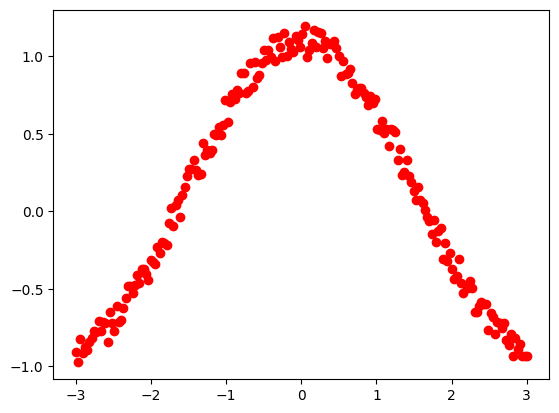

In [ ]:
# Data to be trained on - let's have it fit to a noisy curve
np.random.seed(40)

# f = lambda x: np.exp(x) - x**2
f = lambda x: np.cos(x)
noise_scale = 0.2

x = np.linspace(-3, 3, 200)
y = f(x) + np.random.random(x.shape[0]) * noise_scale

plt.plot(x, y, "ro")
plt.grid(True)
plt.show()

In [8]:
w_start = np.random.random(10)

In [9]:
epochs, batch_size = 500, 2

adam = Adam_Optimizer(0.001)
sgd = SGD_Optimizer(0.001, 0.9, lr_decay=0.01)

adam_l_vect, adam_w = optimize(x, y, epochs, batch_size, adam, w_start, NN, loss, grad)
sgd_l_vect, sgd_w = optimize(x, y, epochs, batch_size, sgd, w_start, NN, loss, grad)

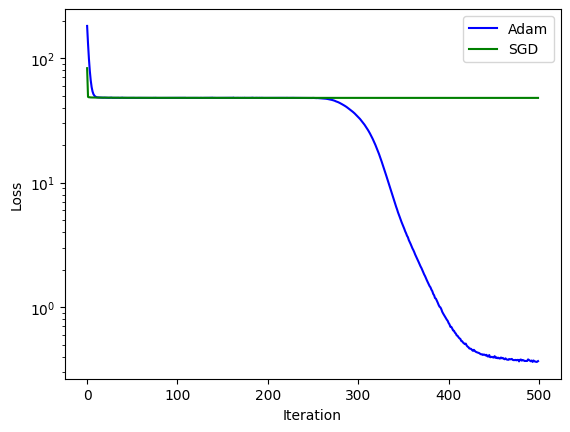

In [ ]:
plt.semilogy(adam_l_vect, "b", sgd_l_vect, "g")
plt.legend(["Adam", "SGD"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True);

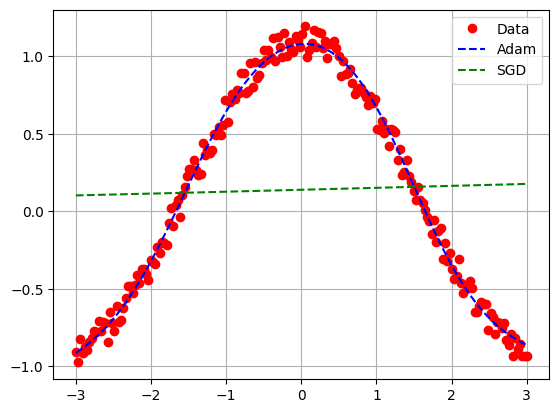

In [21]:
plt.plot(x, y, "ro", x, NN(x, adam_w), "--b", x, NN(x, sgd_w), "--g")
plt.legend(["Data", "Adam", "SGD"])
plt.grid(True)

In [ ]:
# Now let's try using ReLU as an activation function instead!
def ReLU(x):
    return (x + np.abs(x)) / 2

def ReLU_dif_a(a, b, xi):
    return 1/2 * (xi + xi*(a*xi + b))/np.abs(a*xi + b)

def ReLU_dif_b(a, b, xi):
    return 1/2 * (1 + (a*xi+b)/np.abs(a*xi+b))

In [28]:
NN, loss, grad = generate_NN_functions(ReLU, ReLU_dif_a, ReLU_dif_b, 4)

In [29]:
# Added a couple more neurons so new w_start needs to be defined
w_start = np.random.random(13)

In [42]:
epochs, batch_size = 200, 4

adam = Adam_Optimizer(0.001)
sgd = SGD_Optimizer(0.001, 0.9, lr_decay=0.01)

adam_l_vect, adam_w = optimize(x, y, epochs, batch_size, adam, w_start, NN, loss, grad)
sgd_l_vect, sgd_w = optimize(x, y, epochs, batch_size, sgd, w_start, NN, loss, grad)

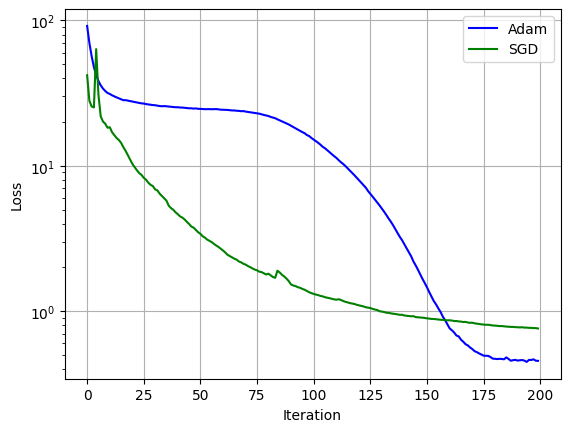

In [43]:
plt.semilogy(adam_l_vect, "b", sgd_l_vect, "g")
plt.legend(["Adam", "SGD"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True);

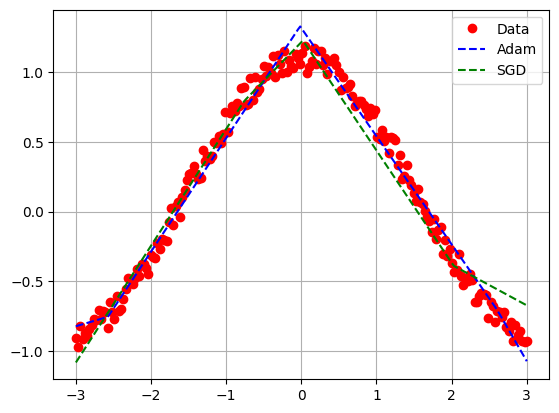

In [44]:
plt.plot(x, y, "ro", x, NN(x, adam_w), "--b", x, NN(x, sgd_w), "--g")
plt.legend(["Data", "Adam", "SGD"])
plt.grid(True)